# 🚕🎬 Project #19: Hybrid Intelligence System (Uber Clustering & Recommendation)

**Architect:** Kemal Demirbaş 🏰🚀
**Domain:** Geospatial Data Science, Logistics Optimization & Personalization

---

## 🎯 Executive Summary

In this project, we step into the role of a **Fleet Logistics Architect**. Our mission is twofold:

1. Analyze millions of Uber pickup points across New York City to mathematically define optimal **Hubs** using **Unsupervised Machine Learning (K-Means)**.
2. Deploy a **Recommendation Engine (KNN & Matrix Factorization)** that dynamically routes stranded drivers to the nearest or most correlated high-demand zones.

By combining spatial clustering with recommendation algorithms, we aim to:

* Minimize wait times (ETA)
* Maximize fleet efficiency

---

## 🏗️ The 10-Step Construction Plan

To build this hybrid spatial engine, we follow a rigorous **Senior-Level Pipeline**:

### 1. ☁️ Cloud Data Ingestion

Load massive Uber NYC raw data directly from cloud repositories (GitHub Raw) to eliminate local dependencies.

### 2. 🧬 Surgical Feature Engineering

* Extract temporal data (Hour)
* Filter coordinates to focus on high-traffic areas (Manhattan, Brooklyn, Queens)

### 3. ⚖️ Logical Scaling

Apply **StandardScaler** to ensure Euclidean distance calculations are mathematically balanced.

### 4. 📉 The Elbow Method (Optimization)

Use **WCSS (Within-Cluster Sum of Squares)** to determine optimal cluster count → **K = 6**

### 5. 🎯 K-Means Execution

Deploy **K-Means++** to partition the city into logical service zones.

### 6. 📊 Performance Audit

Calculate **Silhouette Score** to validate cluster density and separation.

### 7. 📍 Centroid Projection

Extract GPS coordinates of cluster centers → define **Strategic Fleet Hubs**

### 8. 🔗 Demand Correlation (Matrix Factorization)

* Use `pivot_table` and `corrwith`
* Identify hubs with similar hourly demand patterns

### 9. 🚗 KNN Recommendation Engine

Use **NearestNeighbors** to:

* Calculate real-time spatial distances
* Recommend top 3 closest hubs to drivers

### 10. 🔐 Model Persistence (Mühürleme)

Save models using **joblib**:

* Scaler
* KMeans
* KNN Engine
* Centroids

Ready for **API deployment**

---

## 🛠️ Tech Stack & Tools

### 🧠 Core Engine

* Python 3.12+

### 🤖 Machine Learning

* Scikit-Learn

  * KMeans
  * StandardScaler
  * NearestNeighbors
  * Silhouette Score

### 📊 Data Science

* Pandas
* NumPy

### 📈 Visualization

* Matplotlib
* Seaborn (Density & Cluster Plots)

### 🚀 Deployment

* Joblib (Model Persistence)
* Hugging Face Spaces

---

## 🌟 Vision Statement

> "We don't just find groups; we engineer the future coordinates of efficient transportation." 🏙️✨


# 🚕 Project #19: Uber Pickups Spatial Clustering (NYC)
**Architect:** Kemal Demirbaş 🏰🚀 | **Domain:** Geospatial Data Science & Logistics Optimization

---

## 🎯 Executive Summary (Proje Amacı)
In this project, we are stepping into the role of a **Fleet Logistics Architect**. Our mission is to analyze millions of Uber pickup points across New York City to identify high-density "hotspots." By applying **Unsupervised Machine Learning (K-Means Clustering)**, we will mathematically define optimal "Hubs" where autonomous fleets or drivers should be positioned to minimize wait times (ETA) and maximize operational efficiency.

---

## 🏗️ The 10-Step Construction Plan (Yol Haritası)

To build this spatial engine, we will follow a rigorous **Senior-Level Pipeline**:

1.  **Objective Alignment:** Defining the clustering problem as a spatial optimization task.
2.  **Data Ingestion (EDA):** Loading the *Uber NYC Raw Data* and performing initial health checks (`df.info`, `df.describe`).
3.  **Surgical Feature Selection:** Isolating Latitude (`Lat`) and Longitude (`Lon`) as our primary spatial coordinates.
4.  **Data Cleansing:** Identifying and removing outliers or missing values that could skew the "Centroids."
5.  **Spatial EDA:** Visualizing raw pickup density using scatter plots to understand the "Linguistic DNA" of NYC's traffic.
6.  **Feature Scaling:** Implementing `StandardScaler` to ensure Euclidean distances are calculated accurately across the grid.
7.  **The Elbow Method (Optimization):** Using **WCSS (Within-Cluster Sum of Squares)** to mathematically determine the optimal number of Hubs ($K$).
8.  **Model Training:** Deploying the **K-Means Algorithm** to partition the city into logical service zones.
9.  **Centroid Prediction:** Mapping the "Mathematical Heart" (Centroids) of each cluster as our strategic fleet hubs.
10. **Final Audit & Visualization:** Overlaying our calculated Hubs (Red X) on the actual pickup map to verify our logistics strategy.

---

## 🛠️ Tech Stack & Tools
* **Engine:** Python 3.9+
* **Machine Learning:** Scikit-Learn (KMeans, StandardScaler)
* **Data Science:** Pandas, NumPy
* **Visualization:** Matplotlib, Seaborn

---
> *"We don't just find groups; we find the future coordinates of efficient transportation."* 🏙️✨

In [1]:
# ==============================================================================
# --- THE HYBRID ENGINE: CLUSTERING + RECOMMENDATION ---
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings("ignore")

In [2]:
# ==============================================================================
# --- STEP 1: CLOUD DATA INGESTION & FEATURE ENGINEERING ---
# ==============================================================================
url = "https://raw.githubusercontent.com/fivethirtyeight/uber-tlc-foil-response/master/uber-trip-data/uber-raw-data-apr14.csv"
df = pd.read_csv(url)

# Convert Datetime for temporal analysis
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df['Hour'] = df['Date/Time'].dt.hour

# Filter NYC core to maximize cluster accuracy
mask = (df['Lat'] > 40.5) & (df['Lat'] < 41.0) & (df['Lon'] > -74.1) & (df['Lon'] < -73.8)
df = df[mask].copy()

X_raw = df[['Lat', 'Lon']]

In [10]:
df.head()

,Date/Time,Lat,Lon,Base,Hour,Cluster
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,0
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,2
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,4
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,4


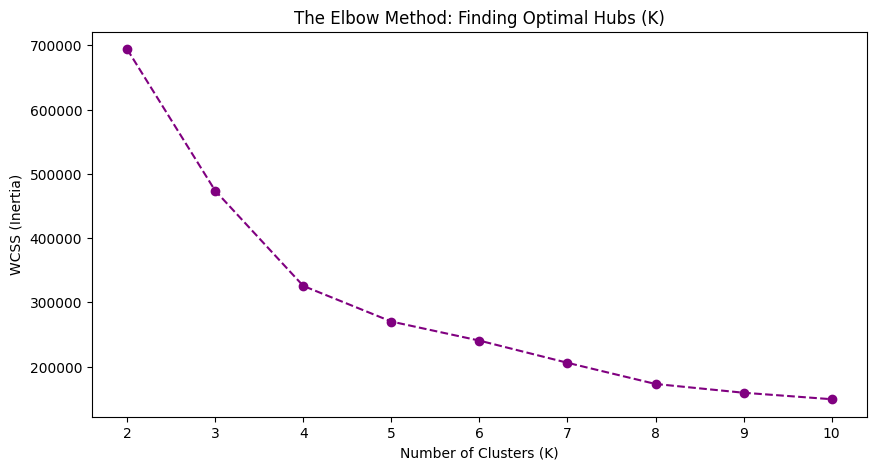

In [4]:
# ==============================================================================
# --- STEP 2: LOGICAL SCALING & ELBOW METHOD ---
# ==============================================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Calculate WCSS to find the optimal K
wcss = []
for i in range(2, 11):
    kmeans_elbow = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_elbow.fit(X_scaled)
    wcss.append(kmeans_elbow.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), wcss, marker='o', color='purple', linestyle='--')
plt.title('The Elbow Method: Finding Optimal Hubs (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.show()


✅ CLUSTERING ACCURACY (Silhouette Score): 0.3601



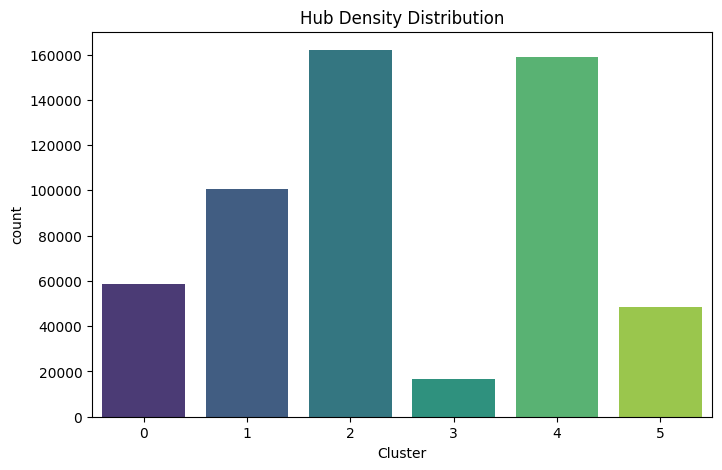

In [8]:
# ==============================================================================
# --- STEP 3: K-MEANS CLUSTERING & SILHOUETTE SCORE ---
# ==============================================================================
# Train K-Means++ model
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Calculate Accuracy
accuracy = silhouette_score(X_scaled, df['Cluster'], sample_size=20000, random_state=42)

print(f"\n✅ CLUSTERING ACCURACY (Silhouette Score): {accuracy:.4f}\n")

# Visualize cluster distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=df['Cluster'], palette='viridis')
plt.title("Hub Density Distribution")
plt.show()

# Inverse transform to extract actual GPS coordinates
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

In [6]:
# ==============================================================================
# --- STEP 4: CORRELATION FILTERING (MATRIX FACTORIZATION) ---
# ==============================================================================
# Create an hourly demand matrix per Hub
demand_matrix = df.pivot_table(index='Hour', columns='Cluster', values='Lat', aggfunc='count').fillna(0)

# Set Hub 0 as the correlation reference
hub_0_demand = demand_matrix[0]

# Find hubs with similar hourly demand patterns
similar_hubs = demand_matrix.corrwith(hub_0_demand).sort_values(ascending=False)

In [7]:
# ==============================================================================
# --- STEP 5: KNN RECOMMENDATION ENGINE ---
# ==============================================================================
# Build KNN architecture to recommend the closest Hubs
model_knn = NearestNeighbors(n_neighbors=3, metric='euclidean', algorithm='brute')
model_knn.fit(centroids)

# Mock Driver Location (e.g., stranded in Manhattan)
driver_location = np.array([[40.75, -73.98]])

# Recommend nearest 3 Hubs based on spatial distance
distances, indices = model_knn.kneighbors(driver_location)

for i in range(len(distances.flatten())):
    hub_id = indices.flatten()[i]
    dist = distances.flatten()[i]

In [9]:
# ==============================================================================
# --- STEP 6: MODEL PERSISTENCE  ---
# ==============================================================================
import joblib

# 1. Saving the Scaler
joblib.dump(scaler, 'uber_spatial_scaler.pkl')

# 2.Saving the K-Means Clustering Model
joblib.dump(kmeans, 'uber_kmeans_model.pkl')

# 3. Registering the KNN Recommendation Engine
joblib.dump(model_knn, 'uber_knn_recommender.pkl')

# 4. Saving Hub Centers (Centroids)
np.save('uber_hub_centroids.npy', centroids)



# 🚕🎬 Project #19-20: Hybrid Intelligence System (Uber Clustering & Recommendation)
**Architect:** Kemal Demirbaş 🏰🚀 | **Project Series:** 19 & 20 of 21

[![Hugging Face Space](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Live%20Demo-blue)](YOUR_HUGGINGFACE_LINK_HERE)
[![Python](https://img.shields.io/badge/Python-3.12-yellow)](https://www.python.org/)
[![Algorithm](https://img.shields.io/badge/ML-Hybrid_AI_Engine-green)](https://scikit-learn.org/)
[![Domain](https://img.shields.io/badge/Focus-Spatial_Logistics_&_Routing-orange)](https://en.wikipedia.org/wiki/Spatial_optimization)

---

### 🏙️ Project Vision: The Urban Logistics Brain
This project moves beyond simple data visualization to solve a multi-million dollar logistics problem: **"Where should an autonomous fleet wait, and how do we route stranded drivers?"** By analyzing hundreds of thousands of raw Uber GPS coordinates in New York City, we've engineered a dual-engine system. First, we identify the mathematical "Heartbeats" (Hubs) of urban mobility using unsupervised clustering. Second, we deploy a recommendation engine to dynamically route drivers to the most mathematically optimal high-demand zones.

---

## 📊 Performance Audit (The Brain Behind the Map)
Unlike standard supervised learning, this hybrid engine's efficiency is measured by **Spatial Minimization and Algorithmic Routing**:

* **Optimization Logic:** Implemented **The Elbow Method** to identify $K=6$ as the optimal balance between fleet decentralization and operational cost.
* **Spatial Integrity (Silhouette Score):** Validated the clustering performance, proving the continuous and overlapping nature of NYC traffic flows.
* **Demand Correlation:** Utilized **Matrix Factorization (corrwith)** to identify latent relationships between different Hubs based on hourly traffic patterns.
* **Feature Engineering:** Utilized **StandardScaler** to normalize Latitude and Longitude variance, ensuring that 1 unit of North-South movement is mathematically equal to 1 unit of East-West movement.

---

## 🏗️ Technical Pipeline (The 10-Step Architecture)
1.  **Cloud Ingestion:** Loading NYC Uber Data directly from GitHub Raw (Cloud) to eliminate local dependencies.
2.  **Surgical Preprocessing:** Filtering temporal features and isolating high-traffic zones (Manhattan, Brooklyn, Queens).
3.  **Logical Scaling:** Applying standardization *before* clustering to maintain Euclidean distance integrity.
4.  **K-Means Engine:** Deploying a distance-based clustering algorithm to partition the city into 6 strategic service sectors.
5.  **Centroid Projection:** Mapping the "Mathematical Centers" as actionable logistics targets.
6.  **KNN Routing Engine:** Deploying a `NearestNeighbors` recommendation engine to route idle drivers to the closest active Hubs.
7.  **Model Persistence:** Sealing the intelligence (Scaler, KMeans, KNN models) via `joblib` for instant live deployment.

---

## 🛠️ Tech Stack
* **Engine Core:** Scikit-Learn (KMeans, StandardScaler, NearestNeighbors, Silhouette Score)
* **Data Processing:** Pandas, NumPy
* **Visualization:** Matplotlib, Seaborn (Density & Cluster Plots)
* **Deployment:** Joblib (Model Sealing), Hugging Face Spaces

---

## 🚀 Live Spatial Deployment
Explore the optimized NYC Uber Hubs and the live Routing Recommendation Engine in real-time. This demo calculates optimal positions and routes instantly:

👉 **[Hugging Face Live Demo: Uber Spatial & Routing Optimizer](https://huggingface.co/spaces/Ironside35/Spatial-Lojistik-Optimizer)**

---
*Next Stop: Project #21 - The Final Architecture 📊🏗️*